In [54]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size ='5' color='black'>ch.10 N차원 배열 다루기</font>
- N차원 배열 객체 : 동일 자료형의 집합
- 2차원 배열 : 행렬과 비슷한 개념
- [NumPy](https://numpy.org/)
- [NumPy API Docs](https://numpy.org/doc/stable/reference/index.html)


# 1. 넘파이 패키지
## 1.1 배열 속성
- NumPy 함수들은 기본적으로 원본을 건드리지 않고 새로운 배열(혹은 View)을 반환하는 것이 원칙 
- 원본을 직접 바꾸는 건 resize(), arr.sort(), 그리고 += 같은 대입 연산

In [4]:
import numpy as np
np.__version__ # tensorflow 2.10 호환 버전

'1.23.5'

In [6]:
# np.arange(from,stop,by) : from부터 stop 전까지 by씩 증가하는 1차원 정수 배열 생성
a = np.arange(15)
print(a.shape) # 배열 구조 및 차원 확인 ; 15 길이를 가진 1차원 배열을 확인
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [24]:
from numpy import arange
a = np.arange(15, dtype=np.int8) #dtype 기본값 : int32
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int8)

In [25]:
type(a)

numpy.ndarray

In [26]:
a.dtype # a 배열의 요소(element)들의 type

dtype('int8')

In [27]:
from numpy import arange
a = np.arange(15).reshape(3,5) # 1행 15열의 1차원 배열을 3행 5열의 2차원 배열로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [20]:
a.itemsize # item 하나의 bytesize

4

In [22]:
a.ndim # 차원 수 확인

2

In [28]:
a.reshape(5,3) # 배열의 구조를 바꾸는게 아닌, 외형만 수정해 출력.

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

## 1.2 배열 타입 변경

In [29]:
a = np.arange(12).reshape(3,4)

In [32]:
a.size, a.dtype, a.itemsize

(12, dtype('int32'), 4)

In [35]:
a.dtype = np.int64
a.dtype, a.itemsize#32bit->64bit 변경되며 itemsize 변경됨

(dtype('int64'), 8)

In [36]:
a 
# 2개의 열이 하나로 합쳐짐(스택) 
# -> 00000001/00000002 [1, 2]
# -> 0000000100000002 [4294967296]
# 스택으로 합쳐진 16진수가 10진수로 표기됨

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [37]:
a.size

6

In [38]:
a = np.arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [40]:
a = a.astype(np.int64)#32bit->64bit
a.dtype

dtype('int64')

In [41]:
a.itemsize

8

In [42]:
a.ravel() # flaten된 배열을 반환

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [43]:
a.flatten()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) / npy(넘파이 포맷, io 개선)

In [167]:
%%time
import time
# start = time.time()
import pickle
with open('data/ch10.pkl', 'wb') as f:
    pickle.dump(a, f)
# end = time.time()
# print('실행 시간 :', end - start)

CPU times: total: 0 ns
Wall time: 1.18 ms


In [168]:
%%time
with open('data/ch10.pkl', 'rb') as f:
    loaded_a = pickle.load(f) # 용량 : 269 B

CPU times: total: 0 ns
Wall time: 13.5 ms


In [170]:
np.all(loaded_a==a)

True

In [166]:
%%time
np.save('data/ch11.npy', a) #넘파이 포맷, 효율 및 안정성 개선, 용량 : 248 B

CPU times: total: 0 ns
Wall time: 2.42 ms


In [56]:
%%time
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 15.6 ms
Wall time: 14.1 ms


In [57]:
loaded_a2 == a

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

# 2. 넘파이 배열
- array() 함수를 이용한 파이썬 데이터(list, tuple) 변환
- 특정 값을 갖는 배열 생성 함수 : ones(), zeros(), empty(), full(), ...
- 랜덤한 값을 갖는 배열 생성 함수 : random.normal() ...
- [NumPy Func](https://numpy.org/doc/stable/reference/index.html)

## 2.1 array() 함수
- array(obj, dtype=np.type(or 'type'), copy=T/F) ; obj:list
    * type : int32, int64, float32, float64, ...

In [59]:
a = np.array([2, 14, 6],
            # dtype=np.int16
            ) # 정수의 기본 타입 : int32 / 실수의 기본 타입 : float64
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [60]:
a[0], a[1]

(2, 14)

In [63]:
for item in a: # 일반적인 list 데이터 탐색과 같음
    print(item, end=' ')

2 14 6 

In [65]:
b = np.array([[1.4, 3.2], # 동일 자료형의 집합으로 배열 생성. 우선 순위 : 정수 → 실수 → 문자
            [3, 5]])
b, b.dtype

(array([[1.4, 3.2],
        [3. , 5. ]]),
 dtype('float64'))

In [73]:
l = [[1.5, 2.3],[4, 5]]
l[0][1]

2.3

In [67]:
b[0,1] # 2차원 [axis0 : 행, axis1 : 열] cf. 1차원 [axis0 : 열]

3.2

In [75]:
a = np.array([[1.5,3.2],
              [4,5]], dtype='float32').reshape(4)
a

array([1.5, 3.2, 4. , 5. ], dtype=float32)

In [78]:
# a의 배열 구조 변경
a.shape = (2, 2)
a

array([[1.5, 3.2],
       [4. , 5. ]], dtype=float32)

In [80]:
#a의 dtype 변경
a = a.astype('float16')
a.dtype

dtype('float16')

In [103]:
for row in a:
    for item in row:
        print(item, end=' ')
    print()

1.5 3.2 
4.0 5.0 


In [104]:
for i, row in enumerate(a):
    for j, item in enumerate(row):
        print(f'[{i}][{j}] {a[i,j]}', end='\t') #float16 : 소수점 이하 불안정
    print()

[0][0] 1.5	[0][1] 3.19921875	
[1][0] 4.0	[1][1] 5.0	


In [101]:
print(b[0,0])
# print(b[0,2]) 존재하지 않는 index 출력은 에러 발생

1.4


In [127]:
# 행과 열의 슬라이싱 : 2차원 배열 데이터 반환
b[:, 1:10] # 전체 행에서 1열부터 10열 전까지 슬라이싱

array([[3.2],
       [5. ]])

In [130]:
# 특정 행(열)의 슬라이싱 : 1차원 배열 데이터 반환
b[0, 1:3] # 0행의 1열부터 3열 전까지 슬라이싱

array([3.2])

In [114]:
ex = np.array([[1,2,3],
              [6,7,8]])

In [125]:
# 모든 행의 마지막 열만 추출
ex[:,-1:], ex[:,-1]

(array([[3],
        [8]]),
 array([3, 8]))

In [128]:
# 모든 행의 마지막 열을 제외한 부분 추출
ex[:,:-1:]

array([[1, 2],
       [6, 7]])

In [132]:
# 스칼라 변수에서
a = 10
b = a
id(a), id(b)

(2525653762576, 2525653762576)

In [147]:
# 스칼라 변수에서
a = 10
b = -1
print(id(a), id(b))

2525653762576 2525653762224


In [146]:
# NumPy 배열에서
c = np.array([[1,2,3],[4,5,6]], dtype='int16') 
d = c #할당.
print(id(c), id(d))

2525806981552 2525806981552


In [151]:
# NumPy 배열에서
c = np.array([[1,2,3],[4,5,6]], dtype='int16') 
d = np.array(c, copy=False) # 할당. d 내용 수정 시 원본 c에도 영향.
print(id(c), id(d))
d[0,0]=9
print(c, d, sep='\n')

2525806980016 2525806980016
[[9 2 3]
 [4 5 6]]
[[9 2 3]
 [4 5 6]]


In [152]:
# NumPy 배열에서
c = np.array([[1,2,3],[4,5,6]], dtype='int16') 
d = np.array(c, copy=False, dtype='int8') # copy=False인 상태에서, dtype이 바뀌면 깊은 복사로 변경됨
print(id(c), id(d))
d[0,0]=9
print(c, d, sep='\n')

2525806969840 2525806980688
[[1 2 3]
 [4 5 6]]
[[9 2 3]
 [4 5 6]]


In [149]:
# NumPy 배열에서
c = np.array([[1,2,3],[4,5,6]], dtype='int16') 
d = np.array(c, copy=True) # 내용을 복사한 독립개체 ; Deep Copy - c.copy()와 동일
print(id(c), id(d))
d[0,0]=9
print(c, d, sep='\n')

2525806980016 2525806979824
[[1 2 3]
 [4 5 6]]
[[9 2 3]
 [4 5 6]]


정보처리에서, u'type' : unsigned 'type' <br>
int8에서 1은 `00000001`으로 표기. <br>
제일 앞의 0은 부호 표기를 담당. (0:+,1:-) <br>
따라서, 1의 경우 `11111110`으로 표기. <br>
unsigned는 해당 이진수를 양수로 읽으므로 uint8에서 -1은 10진수 254를 의미함.

## 2.2 기본값이 있는 배열
- np.zeros(tup, dtype) : 0.0으로 채우기
- np.ones(tup, dtype) : 1.0으로 채우기
- np.full(tup, def, dtype) : def으로 채우기
- np.empty(tup, dtype) : 임의의 값으로 채우기

**위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64으로 설정됨.**

In [206]:
np.zeros((3,5)) # 3행 5열의 2차원 float64 배열에 모든 요소를 0.0으로

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [209]:
np.zeros(5) # 5열의 1차원 float64 배열에 모든 요소를 0.0으로

array([0., 0., 0., 0., 0.])

In [210]:
x = np.zeros((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [213]:
np.ones((4,5), dtype='int16') # 4행 5열의 2차원 int16 배열에 모든 요소를 1으로

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=int16)

In [214]:
np.ones(5) # 5열의 1차원 float64 배열에 모든 요소를 0.0으로

array([1., 1., 1., 1., 1.])

In [216]:
x = np.ones((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [223]:
x = np.full((4,5), 100, dtype='int32')
print(x)
print(x.dtype)

[[100 100 100 100 100]
 [100 100 100 100 100]
 [100 100 100 100 100]
 [100 100 100 100 100]]
int32


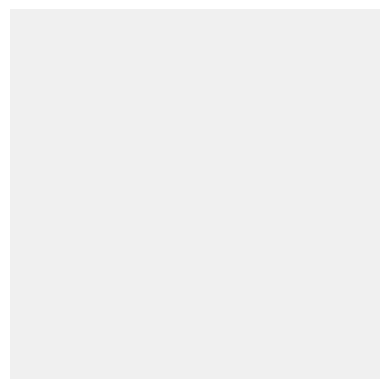

In [233]:
import matplotlib.pyplot as plt
img = np.full((70,70), 240, dtype=np.uint8)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [246]:
np.empty((3,8))

array([[-0.25, -0.5 ,  0.  , -0.25,  0.25, -0.5 ,  0.5 , -0.25],
       [ 0.25,  0.  ,  0.5 ,  0.25,  0.25,  0.5 ,  0.  ,  0.25],
       [-0.25,  0.5 , -0.5 ,  0.25, -0.25,  0.  , -0.5 , -0.25]])

## 2.3 랜덤한 값을 갖는 배열
- np.random.random(tup) : 0 이상 1 미만의 균일한 확률을 가진 무작위 실수
- np.random.uniforn(low, high, size=tup) : low 이상 high 미만의 균일한 확률을 가진 무작위 실수
- np.random.normal(loc, scale, size=tup) : 평균 loc, 표준편차 scale을 가진 정규분포의 무작위 실수
<br><br>
- np.random.rand(n) : 균등분포의 1차원 n개 난수 배열 생성
- np.random.randn(n) : 표준정규분포(평균 0, 표준편차 1)의 1차원 n개 난수 배열 생성
- np.random.randint(n) : 0 이상 n 미만의 정수 난수 1개 발생 == random.randint(1, n-1)
- np.random.randint(low, high, size=tup) : low 이상 high 미만 균일한 확률을 가진 무작위 정수

In [248]:
np.random.random((2,4))

array([[0.21789822, 0.43530375, 0.00162448, 0.34877898],
       [0.17107128, 0.60318086, 0.25228478, 0.80978063]])

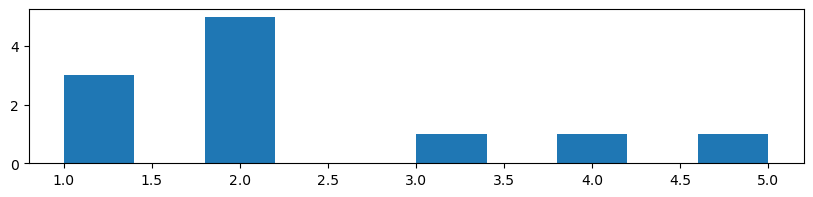

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,2)) # 그래프 사이즈 조절
x = [1, 1, 1, 2, 2, 2, 2, 5, 3, 2, 4]
plt.hist(x, bins=10) # 그래프의 촘촘한 정도
plt.show()

In [2]:
%%time
import matplotlib.pyplot as plt
plt.figure(figsize = (15,5))
x = np.random.randn(50000000)
plt.hist(x, bins=500)
plt.show()

NameError: name 'np' is not defined

<Figure size 1500x500 with 0 Axes>

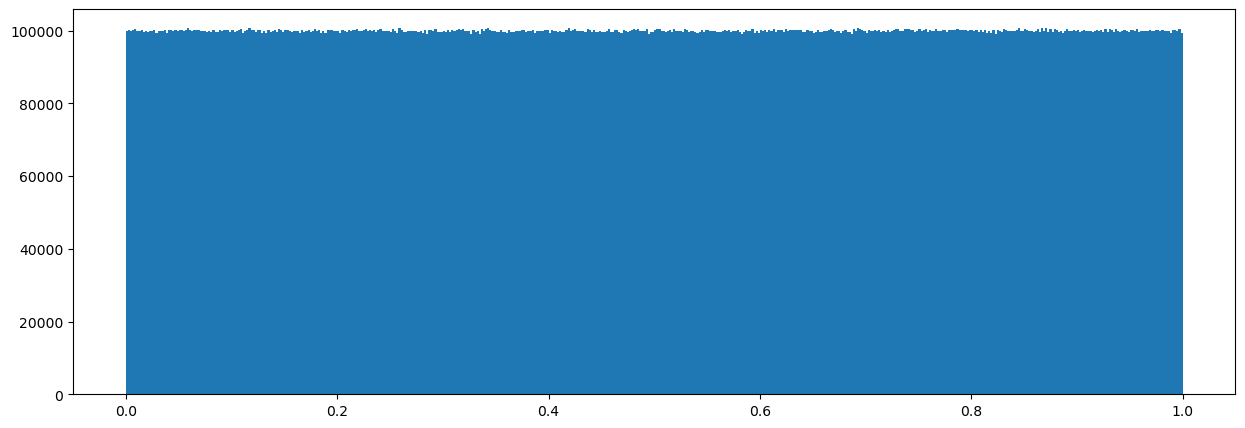

In [334]:
plt.figure(figsize = (15,5))
x =  np.random.rand(50000000)
plt.hist(x, bins=500)
plt.show()

In [15]:
# 2차원 균등분포 난수(0 이상 1 미만 실수 난수) 배열
import numpy as np
np.random.random((2, 5)) # 2행5열짜리 2차원 난수 배열

array([[0.73662351, 0.67124823, 0.9534996 , 0.97502702, 0.33880168],
       [0.35250311, 0.06987587, 0.69580664, 0.15748663, 0.40432465]])

In [5]:
# 2차원 균등분포 난수(-1 이상 1 미만 실수 난수) 배열
np.random.uniform(-1, 1, (2, 5)) #2행 5열 생성

array([[ 0.38750429,  0.40931172, -0.65397141,  0.19325406, -0.80138532],
       [-0.54711452, -0.86305155, -0.7011215 , -0.27542439,  0.94594089]])

In [12]:
# 2차원 정규분포 난수(평균 3, 표준편차 1 실수 난수) 배열
x = np.random.normal(3, 1, (1, 5)) #1행 5열 '2차원' 배열 생성 ; 결과값의 대괄호 2개
x

array([[2.11584032, 5.50228532, 3.49627202, 2.06460619, 2.87787594]])

In [13]:
x[0,1]

5.5022853159861596

In [16]:
# 1차원 균등분포 난수배열
np.random.rand(3)
np.random.random(3)

array([0.4954136 , 0.65466681, 0.30306161])

In [18]:
# 1차원 표준정규분포(평균 0, 표준편차 1인 정규분포) 배열
np.random.randn(3)
np.random.normal(size=3) # loc=0.0, scale=1.0, size=None 순서, loc, scale 없을 시 size 지정 필요 

array([-1.25556141, -0.95906596, -1.13462633])

## 2.4 연속된 값을 갖는 배열
- np.arange(from, to, by, dtype) : from부터 to 전까지 by씩 건너뛴 값을 1차원 배열로 생성
- np.linspace(from, to, n) : from부터 to까지 n개의 숫자를 1차원 배열로 생성

In [31]:
np.arange(10, 24, 2, dtype=np.float32)

array([10., 12., 14., 16., 18., 20., 22.], dtype=float32)

In [53]:
# to가 실수일 때, to 값이 포함될 수 있음
np.arange(1, 2.2, 0.2, dtype=np.float64) 
# 2진수 실수 표기의 한계로 인함. 실제값은 2.199999997이지만 2.2로 출력됨.
# 0.2를 이진수 표기할 경우 무한소수가 되어,파이썬의 계산 상으론 0.19999999..가 더해짐.
# 이로 인해, 실수 배열 생성의 경우 linspace가 더 정교하고 안전함.

array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2])

In [20]:
np.arange(0, 2, 0.4)

array([0. , 0.4, 0.8, 1.2, 1.6])

In [34]:
# arange와 linspace의 차이
print(np.arange(1,5))
print(np.linspace(1,5,5)) #5를 포함. num의 기본값 : 50

[1 2 3 4]
[1. 2. 3. 4. 5.]


In [32]:
x = np.array([0, 1, 2, 3, 4, 5, 6])
y = np.sin(x)

<function matplotlib.pyplot.show(close=None, block=None)>

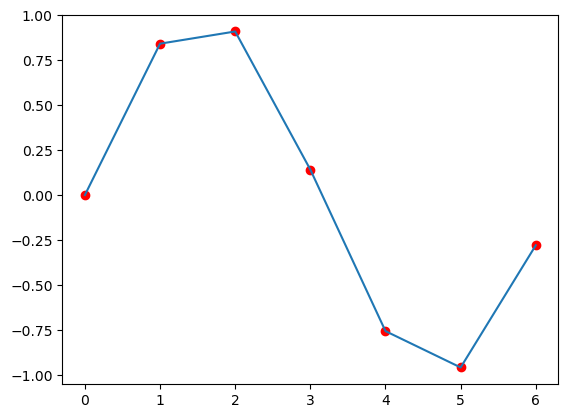

In [36]:
from matplotlib import pyplot as plt
plt.scatter(x, y, c='r') # 빨간색 점그래프
plt.plot(x, y) # 각 점을 이어 선 그래프로 출력
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

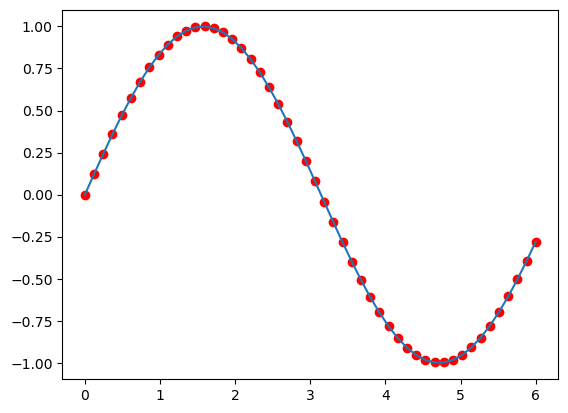

In [49]:
x = np.linspace(0,6,50)
y = np.sin(x)

from matplotlib import pyplot as plt
plt.scatter(x, y, c='r') # 빨간색 점그래프
plt.plot(x, y) # 각 점을 이어 선 그래프로 출력
plt.show

## 2.5 배열의 차원 변경
- reshape(행, 열): -1 사용 가능
    - 원본의 총 원소 개수와 바꿀 모양의 총 원소 개수가 반드시 일치해야함
    - 원본 데이터는 그대로 두고, 모양이 바뀐 "새로운 뷰(View)"를 반환함
- resize(tup): -1 사용 불가
    - 원본 배열 자체를 직접 변경
    - 원본과 원소 개수가 달라도 작동
- ravel() : 1차원 배열(View)을 반환, ravel()로 만든 배열의 값을 수정할 경우, 원본도 함께 바뀜
- flatten() : 1차원으로 변경한 새로운 복사본(Copy) 배열을 반환
- T, transpose() : 전치(행과 열을 바꿈)행렬로 View 반환

In [57]:
t = np.random.random((2,5))
print(t)
print(t*10)

[[0.37128639 0.47418708 0.06817543 0.23954273 0.37663431]
 [0.45199251 0.07564766 0.58610699 0.91056787 0.24894823]]
[[3.71286393 4.74187084 0.68175425 2.39542733 3.76634306]
 [4.51992514 0.75647661 5.86106985 9.10567867 2.48948233]]


In [58]:
# t*10 각 요소의 결과값 반환
# round(t*10) 각 요소의 스칼라 값을 반올림
a = np.round(t*10)
a

array([[4., 5., 1., 2., 4.],
       [5., 1., 6., 9., 2.]])

In [61]:
a = a.astype(np.int16) # 실행 결과가 나올 경우, 원본 a엔 영향이 없으므로 원본 변경 시 a에 재할당 필요.
a

array([[4, 5, 1, 2, 4],
       [5, 1, 6, 9, 2]], dtype=int16)

In [63]:
a.reshape(5,-1) 
# -1 : 요소의 개수에 맞춰 행(열)의 개수를 자동 계산, 행과 열 중 기준점이 필요함 ; (-1, -1) 불가

array([[4, 5],
       [1, 2],
       [4, 5],
       [1, 6],
       [9, 2]], dtype=int16)

In [65]:
a.resize((2,5)) # 실행 결과가 없을 경우, 원본 a에도 영향이 있음

In [66]:
a

array([[4, 5, 1, 2, 4],
       [5, 1, 6, 9, 2]], dtype=int16)

In [67]:
a.resize(-1) # -1 사용불가

ValueError: negative dimensions not allowed

In [68]:
a.ravel() # 원본 a에 영향 없음

array([4, 5, 1, 2, 4, 5, 1, 6, 9, 2], dtype=int16)

In [69]:
a

array([[4, 5, 1, 2, 4],
       [5, 1, 6, 9, 2]], dtype=int16)

In [70]:
a.flatten() # 원본 a에 영향 없음

array([4, 5, 1, 2, 4, 5, 1, 6, 9, 2], dtype=int16)

In [71]:
a

array([[4, 5, 1, 2, 4],
       [5, 1, 6, 9, 2]], dtype=int16)

In [72]:
a.T # 각 행과 열을 전치함, 원본 a에 영향 없음

array([[4, 5],
       [5, 1],
       [1, 6],
       [2, 9],
       [4, 2]], dtype=int16)

In [73]:
a

array([[4, 5, 1, 2, 4],
       [5, 1, 6, 9, 2]], dtype=int16)

## 2.6 배열 인쇄

In [79]:
print(np.arange(10000).reshape(100, 100)+1) # item 개수 최대 1000개까지 출력됨

[[    1     2     3 ...    98    99   100]
 [  101   102   103 ...   198   199   200]
 [  201   202   203 ...   298   299   300]
 ...
 [ 9701  9702  9703 ...  9798  9799  9800]
 [ 9801  9802  9803 ...  9898  9899  9900]
 [ 9901  9902  9903 ...  9998  9999 10000]]


In [78]:
np.get_printoptions()['threshold'] # 출력 최댓값

1000

In [86]:
# 배열의 요소가 많아 출력할 수 없는 경우, 일부를 생략하고 모서리 부분만 출력함
# 넘파이 출력 옵션 변경 (출력 사이즈 조정)
np.set_printoptions(threshold=10000) # 10,000개 출력

np.set_printoptions(threshold=np.inf) # np.inf = 무한대

import sys
np.set_printoptions(threshold=sys.maxsize) # 파이썬 시스템의 가장 큰 수(약 920경)

In [81]:
print(np.arange(10000).reshape(100, 100)+1)

[[    1     2     3     4     5     6     7     8     9    10    11    12
     13    14    15    16    17    18    19    20    21    22    23    24
     25    26    27    28    29    30    31    32    33    34    35    36
     37    38    39    40    41    42    43    44    45    46    47    48
     49    50    51    52    53    54    55    56    57    58    59    60
     61    62    63    64    65    66    67    68    69    70    71    72
     73    74    75    76    77    78    79    80    81    82    83    84
     85    86    87    88    89    90    91    92    93    94    95    96
     97    98    99   100]
 [  101   102   103   104   105   106   107   108   109   110   111   112
    113   114   115   116   117   118   119   120   121   122   123   124
    125   126   127   128   129   130   131   132   133   134   135   136
    137   138   139   140   141   142   143   144   145   146   147   148
    149   150   151   152   153   154   155   156   157   158   159   160
    161   1

In [88]:
# 커널 초기화 또는 재설정 시 축약 출력 가능
import numpy as np
np.set_printoptions(threshold=1000)
np.arange(10000).reshape(100, 100)

array([[   0,    1,    2, ...,   97,   98,   99],
       [ 100,  101,  102, ...,  197,  198,  199],
       [ 200,  201,  202, ...,  297,  298,  299],
       ...,
       [9700, 9701, 9702, ..., 9797, 9798, 9799],
       [9800, 9801, 9802, ..., 9897, 9898, 9899],
       [9900, 9901, 9902, ..., 9997, 9998, 9999]])

## 2.7 기본 연산 동작 방식

### 1) 배열의 요소별 연산

In [94]:
a = np.array([10,20,30,40], dtype=np.int8)
b = np.arange(4)
print(a) # 배열을 print 시 array 표기와 ',' 없이 출력됨 ; 리스트와의 차이점
print(b)
print(a.dtype, b.dtype)

[10 20 30 40]
[0 1 2 3]
int8 int32


In [95]:
c = a + b # 배열의 요소별 + 연산
print(c)
print(c.dtype) # dtype이 다를 경우, 좁은 개념의 타입(int8)이 더 넓은 개념의 타입(int32)으로 변경됨

[10 21 32 43]
int32


In [97]:
a * 2

array([20, 40, 60, 80], dtype=int8)

In [98]:
a * b # int8에서 int32로 변경

array([  0,  20,  60, 120])

In [100]:
a < 40 # 각 요소별 T/F 반환

array([ True,  True,  True, False])

In [107]:
print(a[[0,1,2]]) # 배열의 index를 list로 입력 (팬시 인덱싱)
print(a[[True, True, True, False]]) #boolean index, 요소의 개수에 맞춰 입력 필요

[10 20 30]
[10 20 30]


In [ ]:
print(a[0,1,2]) # 3차원 배열의 좌표 (현재 a의 데이터는 1차원이므로 오류 발생)

In [105]:
# a 배열에서 40 미만인 데이터 추출을 위해 boolean index 사용하기
a[a<40]

array([10, 20, 30], dtype=int8)

In [110]:
# a 배열에서 40 미만인 데이터의 index 확인을 위해 where 사용하기
np.where(a<40)

(array([0, 1, 2], dtype=int64),)

### 2) 행렬 곱연산
- @, dot 함수 cf. *(요소별 곱연산)
- 2차원 배열은 행렬로 취급

In [112]:
A = np.array([[1,1],[0,1]])
B = np.array([[2,0],[3,4]])

In [115]:
print('요소별 곱 A*B =', A*B, sep='\n')
print('행렬 곱연산 1. A@B =', A@B, sep='\n')
print('행렬 곱연산 2. A.dot(B) =', A.dot(B), sep='\n')
print('행렬 곱연산 3. np.dot(A, B) =', np.dot(A, B), sep='\n')

요소별 곱 A*B =
[[2 0]
 [0 4]]
행렬 곱연산 1. A@B =
[[5 4]
 [3 4]]
행렬 곱연산 2. A.dot(B) =
[[5 4]
 [3 4]]
행렬 곱연산 3. np.dot(A, B) =
[[5 4]
 [3 4]]


In [120]:
A = np.array([[0,0],[1,1],[-1,2]])
B = np.array([[1,2,3],[3,4,1]])

In [122]:
A@B, B@A

(array([[ 0,  0,  0],
        [ 4,  6,  4],
        [ 5,  6, -1]]),
 array([[-1,  8],
        [ 3,  6]]))

In [123]:
# 단위행렬 : A@B와 B@A가 같은 행렬, B가 단위행렬(I)일 경우, A@I = I@A  = A, 정방행렬의 특성을 가짐
A = np.array([[1,0],[0,1]])
B = np.array([[1,2],[3,4]])

In [125]:
print(A@B, B@A, sep='\n')

[[1 2]
 [3 4]]
[[1 2]
 [3 4]]


### 3) 복합 대입 연산자
- +=, -=, ...
- 배열에서, (a+=b)와 (a=a+b)는 차이가 존재
    - a+=b : 주소 유지, 원본 변경 가능
    - a=a+b : 새로운 복사 개체 생성

In [141]:
a = np.ones((2,3), dtype=np.int8) #int8
b = np.random.random((2,3)) #float64
print(a, b, sep='\n')

[[1 1 1]
 [1 1 1]]
[[0.17347559 0.75683647 0.19058354]
 [0.74066123 0.74703258 0.75351045]]


In [142]:
a += 5 # a = a + 5
a

array([[6, 6, 6],
       [6, 6, 6]], dtype=int8)

In [143]:
a += 255 # int8 내의 공간 부족 발생으로 오류 발생
a

array([[5, 5, 5],
       [5, 5, 5]], dtype=int8)

In [144]:
a = a + 255 # 새로운 복사 개체 생성, 크기에 따라 dtype 변경됨
a

array([[260, 260, 260],
       [260, 260, 260]], dtype=int16)

In [145]:
b += a
b

array([[260.17347559, 260.75683647, 260.19058354],
       [260.74066123, 260.74703258, 260.75351045]])

In [147]:
a += b # a+b(int8 -> float64)를 기존 a(int 16)로 반환 ; 오류 발생

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int16') with casting rule 'same_kind'

### 4) 배열 요소별 집계
- sum, min, max, mean, var(분산), std(표준편차)

In [158]:
a = np.array([[2,2,2,3],
              [4,3,2,1]])

In [155]:
print(f'전체    합   : {a.sum()}, {np.sum(a)}')
print(f'전체  최솟값  : {a.min()}, {np.min(a)}')
print(f'전체  최댓값  : {a.max()}, {np.max(a)}')
print(f'전체   평균  : {a.mean()}, {np.mean(a)}')
print(f'전체   분산  : {a.var()}, {np.var(a)}')
print(f'전체 표준편차 : {a.std()}, {np.std(a)}')

전체    합   : 19, 19
전체  최솟값  : 1, 1
전체  최댓값  : 4, 4
전체   평균  : 2.375, 2.375
전체   분산  : 0.734375, 0.734375
전체 표준편차 : 0.8569568250501305, 0.8569568250501305


In [156]:
# 분산의 제곱근 : 표준편차
import math
math.sqrt(a.var())

0.8569568250501305

### 5) 배열 축별 집계
- 1차원 : axis0 = 열
- 2차원 : axis0 = 행, axis1 = 열
- 3차원 : axis0 = 면, axis1 = 행, axis2 = 열
- 각 축의 sum, min, max, mean, var ,std

In [166]:
print(f'a의 행 축 합 : {a.sum(axis=0)}')  # 행 방향으로 이동하며 연산, 세로줄끼리 더해짐

a의 행 축 합 : [6 5 4 4]


In [168]:
print(f'a의 열 축 합 : {np.sum(a, axis=1)}')  # 열 방향으로 이동하며 연산, 가로줄끼리 더해짐

a의 열 축 합 : [ 9 10]


In [169]:
# 3차원 배열의 집계
b = np.arange(24).reshape(2, 3, 4) # 2면 3행 4열
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [178]:
b[0,1,2] # 3차원 인덱싱

6

In [177]:
b.sum(), b.mean(), b.std() # 3차원 배열 전체에 대한 집계

(276, 11.5, 6.922186552431729)

In [180]:
b.sum(axis=0) # 면 축 합 ; 행과 열을 고정

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [183]:
b.sum(axis=1) # 행 축 합 ; 면과 열을 고정

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [184]:
b.sum(axis=2) # 열 축 합 ; 면과 행을 고정

array([[ 6, 22, 38],
       [54, 70, 86]])

In [188]:
b.sum(axis=1).sum(axis=0) # 면,행 축 합 ; 열만 고정

array([60, 66, 72, 78])

### 2.8 범용 함수
- np.sqrt() : 제곱근
- np.add(A, B, C) : C = np.add(A, B) | C = A + B 와 같은 의미를 가짐.
    * C = np.add(A, B)와 C = A + B의 차이점 : add는 조건부 연산과 out 매개변수 사용 가능
- np.multiply(A, B, C) : C = np.multiply(A, B) | C = A * B
- np.subtract(A, B, C) : C = np.subtract(A, B) | C = A - B

In [189]:
a = np.array([1,4])
b = np.array([3,4])
c = np.empty(2)
a, b, c

(array([1, 4]), array([3, 4]), array([1.29474746e-311, 0.00000000e+000]))

In [191]:
np.sqrt(a)

array([1., 2.])

In [192]:
np.add(a, b, c)

array([4., 8.])

In [193]:
np.multiply(a, b, c)

array([ 3., 16.])

In [194]:
np.subtract(b, a, c)

array([2., 0.])

## 2.9 브로드케스팅
- 서로 다른 크기의 배열간 연산 수행을 돕는 기능
    - 한 차원씩 비교할 때, 두 배열의 차원 크기가 같을 경우
    - 둘 중 하나의 차원 크기가 1일 경우

In [195]:
# 1차원 배열의 경우
a = np.array([1, 2, 3])
b = np.array([10, 10, 10])
print(a+b)

[11 12 13]


In [197]:
# 1차원 배열과 스칼라 데이터의 연산 - 두 데이터의 차원 크기가 1일 경우
A = np.array([1, 2, 3])
print(A + 10)

[11 12 13]


In [199]:
# 2차원 배열의 브로드케스팅 - 두 데이터를 한 차원씩 비교할 때, 두 배열의 차원 크기가 같을 경우
a = np.array([[0,0,0],
            [10,10,10],
            [20,20,20],
            [30,30,30]]) # 4*3 배열
b = np.array([1, 2, 3]) # a와 b가 모두 3열 -> 브로드케스팅 가능
a + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [201]:
# 2차원 배열의 브로드케스팅 - 두 데이터를 한 차원씩 비교할 때, 두 배열의 차원 크기가 같을 경우
a = np.array([[0,0,0],
            [10,10,10],
            [20,20,20],
            [30,30,30]]) # 4*3 배열
b = np.array([[1],
              [2],
              [3],
              [4]]) # a와 b가 모두 4행 -> 브로드케스팅 가능
a + b

array([[ 1,  1,  1],
       [12, 12, 12],
       [23, 23, 23],
       [34, 34, 34]])

In [208]:
# 브로드케스팅이 불가한 경우
a = np.array([[0,0,0],
            [10,10,10],
            [20,20,20],
            [30,30,30]]) # 4*3 배열
b = np.array([[1],
              [2],  # a는 3열, b는 1열
              [3]]) # a는 4행, b는 3행 -> 브로드케스팅 불가

In [209]:
# np.newaxis 연산자를 이용하여 배열에 새로운 축을 추가
a = np.array([0, 10, 20, 30]) # 1차원
# 2차원으로 변경
A = a[:, np.newaxis] 
# newaxis 외 축 확장
A = a.reshape(4, 1)
A = np.expand_dims(a, axis=1)
A

array([[ 0],
       [10],
       [20],
       [30]])

In [211]:
# a와 b의 모든 쌍 조합에 대한 계산 시 1)브로드캐스팅 특성 활용, 2)np.ix_함수 이용
b = np.array([1, 2, 3])
A + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [213]:
ax, bx = np.ix_(a, b) # 서로 다른 1차원 배열들을 가지고 격자를 짜기 위해, 강제로 차원을 1로 만들어 주는 함수
ax + bx

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

# 3. 배열 합치기/분리하기
- 슬라이싱
- r_, c_
- 두 배열을 합치는 함수
- 하나의 배열을 여러 배열로 분리하는 함수

## 3.1 다차원 배열 인덱싱과 슬라이싱
[indexing](https://docs.scipy.org/doc/numpy/user/basics.indexing.html) <br>
[newaxis](https://numpy.org/doc/stable/reference/constants.html#numpy.newaxis)

In [215]:
b = np.arange(20).reshape(5,-1)

In [217]:
b[2, 1] # 인덱스 범위를 벗어날 경우 오류 발생

9

In [219]:
# 모든 행의 마지막 열 앞까지(용도 : 종속변수 제외)
b[:,:-1] # 모든 행의 경우, 선행 축은 생략 불가능 ex) b[,:-1] >>> Error

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [222]:
# 모든 열의 0~2행
b[:3,...]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [223]:
b[3:,2:]

array([[14, 15],
       [18, 19]])

## 3.2 배열 합치기
- 두 배열을 쌓아 합치는 함수
    * vstack(tup) : 아래로 추가하는 방식 (Vertical)
    * hstack(tup) : 옆으로 추가하는 방식 (Horizontal)
    * dstack(tup) : 깊이로 추가하는 방식 (Depth) ; 차원 증가

In [226]:
c = np.array([1,2,3])
d = np.array([4,5,6])
v = np.vstack((c,d))
print('vstack - ', v, 'shape - ',v.shape, sep='\n')
h = np.hstack((c,d))
print('hstack - ', h, 'shape - ',h.shape, sep='\n')
d = np.dstack((c,d))
print('dstack - ', d, 'shape - ',d.shape, sep='\n')

vstack - 
[[1 2 3]
 [4 5 6]]
shape - 
(2, 3)
hstack - 
[1 2 3 4 5 6]
shape - 
(6,)
dstack - 
[[[1 4]
  [2 5]
  [3 6]]]
shape - 
(1, 3, 2)


In [227]:
c = np.arange(24).reshape(2, 3, 4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [229]:
a, b = c # 면 별로 할당
a, b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [230]:
v = np.vstack((a,b))#= np.concatenate((a,b), axis=0)
print('vstack - ', v, 'shape - ',v.shape, sep='\n')
h = np.hstack((a,b))#= np.concatenate((a,b), axis=1)
print('hstack - ', h, 'shape - ',h.shape, sep='\n')
d = np.dstack((a,b))
print('dstack - ', d, 'shape - ',d.shape, sep='\n')

vstack - 
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]
shape - 
(6, 4)
hstack - 
[[ 0  1  2  3 12 13 14 15]
 [ 4  5  6  7 16 17 18 19]
 [ 8  9 10 11 20 21 22 23]]
shape - 
(3, 8)
dstack - 
[[[ 0 12]
  [ 1 13]
  [ 2 14]
  [ 3 15]]

 [[ 4 16]
  [ 5 17]
  [ 6 18]
  [ 7 19]]

 [[ 8 20]
  [ 9 21]
  [10 22]
  [11 23]]]
shape - 
(3, 4, 2)


- column_stack(tup) : 1차원 배열을 2차원 배열의 열단위로 합치기
- row_stack(tup) : 행 단위로 합치기 == vstack()

In [231]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9, 10, 11, 12])

In [232]:
np.column_stack((a,b,c))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [236]:
np.hstack((a[:,np.newaxis], b[:,np.newaxis], c[:,np.newaxis]))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [240]:
np.row_stack((a, b, c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [241]:
np.vstack((a, b, c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

- stack(tup, axis=n) : axis 속성에 따라 배열을 합침
    - axis = 
        * 0: 첫번째 차원(면, 행, 열) <br>
        * 1: 두번째 차원(행, 열, -) <br>
        * -1: 마지막 차원(열, -, -) <br>


In [257]:
c = np.arange(24).reshape(2, 3, 4)
a,b = c
a,b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [258]:
np.stack((a,b), axis=0) # 2차원 배열끼리 stack시, 3차원 axis=0(면)으로 합치기

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [247]:
np.stack((a,b), axis=1) # axis=1 행끼리 합치기

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

In [248]:
np.stack((a,b), axis=2) # dstack과 동일한 결과

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

## 3.3 r_, c_
* 나열 객체

In [250]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9,10,11,12])

In [251]:
np.r_[a, b, c] # 하나의 행으로

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [253]:
np.r_[[a],[b],[c]]

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [254]:
np.c_[a, b, c] # 컬럼 단위로 stack (c_와 column_stack을 가장 자주 사용함)

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

## 3.4 배열 분리하기

<br>

**int를 넣을 때, 나누어 떨어져야함**
- vsplit(ary, int or vector) : 첫번째 축(axis=0)을 따라 분할
- hsplit(ary, int or vector) : 두번째 축(axis=1)을 따라 분할
- split(ary, int or vector, axis) 

<br>

**int를 넣을 때, 나누어 떨어지지 않아도 사용 가능**
- array_split(ary, int or vector, axis)

In [259]:
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [263]:
a_split = np.vsplit(a, [2]) #가로축(axis=0)을 따라 2번 index 앞에서 분할
a_split

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [264]:
a_split = np.hsplit(a, 2) #세로축(axis=1)을 따라 2개로 분할
a_split

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [266]:
a_split = np.hsplit(a, [3]) #세로축(axis=1)을 따라 3번 index 앞에서 분할
a_split

[array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [270]:
np.split(a, 3, axis=0) # axis=0으로 분리, 2차원에서의 vsplit(a, 3)과 동일

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [271]:
np.split(a, 2, axis=1) # axis=1으로 분리, 2차원에서의 hsplit(a, 2)과 동일

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [272]:
np.array_split(a, 2, axis=0) # 나눠지지 않는 정수일 경우, 임의로 2, 1 묶음으로 분할함

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [274]:
np.split(a, [1], axis=0) 
# 나눠지지 않는 정수일 경우, 사용자 정의대로 1, 2 묶음으로 분할함
# 1번 index 앞에서 분리

[array([[0, 1, 2, 3]]),
 array([[ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])]

# 4. 복사와 뷰

## 4.1 할당

In [154]:
# 스칼라 변수에서
a = 10
b = a
print('a와 b 주소 :', id(a), id(b))

b = 9
print('a와 b 주소 :', id(a), id(b))
print('수정 후 데이터 :', a, b)

a와 b 주소 : 2525653762576 2525653762576
a와 b 주소 : 2525653762576 2525653762544
수정 후 데이터 : 10 9


In [157]:
# 배열에서
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [158]:
b = a
# b = = np.arange(12)와 같음
print(a.shape, type(a), a.ndim, id(a))
print(b.shape, type(b), b.ndim, id(b))

(12,) <class 'numpy.ndarray'> 1 2525806980592
(12,) <class 'numpy.ndarray'> 1 2525806980592


In [160]:
a is b

True

In [161]:
a == b # 요소별 비교

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [171]:
np.all(a==b) #np.all() array 배열 안의 모든 값이 True인지 여부

True

In [172]:
b.shape = (3, 4)

In [174]:
print(a)
print(b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


## 4.2 뷰(View)
- 얕은 복사 (Shallow Copy)

In [175]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [176]:
c = a.view() #얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [181]:
print('a와 c 주소 :', id(a), id(c))

a와 c 주소 : 2525806970128 2525806977232


In [177]:
np.all(a==c)

True

In [178]:
a is c

False

In [180]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [182]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [183]:
# 배열 복사본 c의 특정 요소만 수정
c[1,::2]=-99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [184]:
a # 원본 a도 함께 수정됨

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [186]:
# 슬라이싱 시 view가 반환 (shape과 dtype 외의 변경은 원본에 영향)
a = np.array([[99, 88, 77, 85],
              [95, 83, 79, 90],
              [97, 89, 72, 92]])
X = a[:,:-1]#.view()와 동일
X

array([[99, 88, 77],
       [95, 83, 79],
       [97, 89, 72]])

In [191]:
X[0:2,-1] = 1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [95, 83,  1],
       [97, 89, -1]])

In [192]:
a # <<< view를 수정했기 때문에 원본도 수정됨.

array([[99, 88,  1, 85],
       [95, 83,  1, 90],
       [97, 89, -1, 92]])

## 4.3 깊은 복사

In [196]:
a = np.array([[99, 88, 77, 85],
              [95, 83, 79, 90],
              [97, 89, 72, 92]])
a

array([[99, 88, 77, 85],
       [95, 83, 79, 90],
       [97, 89, 72, 92]])

In [198]:
X = a[:,:-1].copy() # 슬라이싱으로 view 생성 후, 깊은 복사하여 독립된 개체 생성
X = np.array(a[:,:-1], copy=True) # 깊은 복사
X

array([[99, 88, 77],
       [95, 83, 79],
       [97, 89, 72]])

In [199]:
X[:,0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1, 77],
       [ 1,  1, 79],
       [ 1,  1, -1]])

In [200]:
a

array([[99, 88, 77, 85],
       [95, 83, 79, 90],
       [97, 89, 72, 92]])

# 5. 고급 인덱싱

## 5.1 인덱스 배열

In [275]:
a = np.arange(12)**2
a

array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100, 121])

In [276]:
a[[0, 5, 9]] # [0, 5, 9] : 인덱스 배열

array([ 0, 25, 81])

In [277]:
a[[0, 1, 1, 5]]

array([ 0,  1,  1, 25])

In [278]:
# 인덱싱하기 위한 값을 1차원 배열로
idx_ary = np.array([0, 5, 5, 8])
a[idx_ary] 

array([ 0, 25, 25, 64])

In [280]:
# 인덱싱하기 위한 값을 2차원 배열로
idx_ary = np.array([[0, 5], [5, 8]])
a[idx_ary] # 반환 값은 인덱싱 배열의 형태를 따라감

array([[ 0, 25],
       [25, 64]])

In [281]:
a[idx_ary] = -9
a

array([ -9,   1,   4,   9,  16,  -9,  36,  49,  -9,  81, 100, 121])

In [282]:
a[idx_ary] += 9 # 0, 5, 8 번째의 값이 영향. 복합대입연산자는 중복 x (5번 index에서 한번만)
a

array([  0,   1,   4,   9,  16,   0,  36,  49,   0,  81, 100, 121])

## 5.2 argmax
- 최댓값이 있는 인덱스를 반환

In [283]:
data = np.sin(np.arange(20).reshape(5,4))
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021],
       [-0.53657292,  0.42016704,  0.99060736,  0.65028784],
       [-0.28790332, -0.96139749, -0.75098725,  0.14987721]])

In [286]:
# 각 열에서 최댓값인 행의 index 리스트
ind = data.argmax(axis=0) 
ind

array([2, 0, 3, 1], dtype=int64)

In [289]:
# 제일 큰 값 찾기 (ind[n] : n번째 열에서 최댓값인 행의 index)
data[ind[0], 0], data[ind[1], 1]

(0.9893582466233818, 0.8414709848078965)

In [290]:
#data[행_위치_리스트, 열_위치_리스트]
data_col_max = data[ind, range(data.shape[1])]
# range(data.shape[1])=배열의 열(Column) 개수인 4, range(4)는 [0, 1, 2, 3]
data_col_max

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [291]:
data.max(axis=0)

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [293]:
# 두 배열이 같은지 여부 확인
np.all(data_col_max == data.max(axis=0))

True

## 5.3 boolen index
- 논리 배열을 이용한 인덱싱

In [294]:
a = np.arange(20)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [295]:
a%2==0

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False])

In [297]:
# 배열에서 원하는 조건의 요소만 추출
a[a%2==0]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [298]:
a[[ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False]]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [300]:
a[a>=10]

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

# 6. 선형 대수
- 2차원 배열에 대한 행렬연산
    * 행렬곱 : @, np.dot()
    * 역행렬 : np.linalg.inv(X)
    * 전치행렬 : X.T, X.transpose()
    * 대각합 : np.trace(x)

<img src="https://blog.kakaocdn.net/dna/444IE/btqYKaRk1gS/AAAAAAAAAAAAAAAAAAAAAOlG0Y6p4XpvTgYou9k3aW4VwtH2-K4A61CnNWD1UhLg/img.jpg?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1785509999&allow_ip=&allow_referer=&signature=yVKMv7SY28sGjG4YykrL3KzDzYM%3D"
     width="200"
     style="float:center">